In [1]:
# ── Cell 2
# Core utilities
import os
import time
import warnings
import random
from argparse import Namespace

# Data & Numerical Computing
import numpy as np

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random


# ─────────────────────────────────────────────────────────────────────────────
# Global Configuration & Seeding
# ─────────────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key (used across all cells, including main())
JAX_KEY = None

def seed_everything(seed=42):
    """Set global seed for reproducibility across NumPy, Python random, and JAX."""
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

# Initialize global seed (this JAX_KEY will be used in main() function)
seed_everything(42)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

# ─────────────────────────────────────────────────────────────────────────────
# JIGSAWS Dataset Directory Resolution
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path

# 1. Safely mount Google Drive ONLY if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Ignores the error if running on Kaggle or locally

# 2. Define potential paths using modern pathlib syntax (cleaner than os.path.join)
cwd = Path.cwd()
candidates = [
    Path('/content/drive/MyDrive/JIGSAWS/Suturing/Suturing'),
    cwd / 'JIGSAWS_datasets' / 'JIGSAWS' / 'Suturing' / 'Suturing',
    cwd / 'JIGSAWS' / 'Suturing' / 'Suturing',
    cwd / 'Suturing' / 'Suturing'
]

# 3. Find the first valid directory using a clean generator expression
JIGSAWS_ROOT = next((path for path in candidates if path.is_dir()), None)

if JIGSAWS_ROOT is None:
    raise FileNotFoundError("Could not find JIGSAWS_ROOT in any candidate paths.")

print(f'JIGSAWS_ROOT = {JIGSAWS_ROOT}')

# ─────────────────────────────────────────────────────────────
print('✓ All required libraries imported and configured.')

Mounted at /content/drive
JIGSAWS_ROOT = /content/drive/MyDrive/JIGSAWS/Suturing/Suturing
✓ All required libraries imported and configured.


In [2]:
# ── Cell 3 ·
# JIGSAWS data-loading utilities — interaction-only ──────────────
import numpy as np
import jax.numpy as jnp
from jax import jit
from pathlib import Path

global H_DATA_GEN
DT = 1.0 / 30.0  # 30 Hz
H_DATA_GEN = DT
FPS = 30

# ── Hand-annotated needle-tissue interaction intervals (seconds) ──────────────
INTERACTION_TIMES = {
    'B001': [(0,10),(23,32),(38,47),(60,79),(92,102),(124,135),(147,160),(169,180)],
    'B002': [(20,30),(47,60),(70,90),(100,109)],
    'B003': [(1,5),(10,20),(34,43),(52,70),(80,100)],
    'B004': [(5,25),(38,49),(59,75),(89,100)],
    'B005': [(16,34),(42,50),(62,72),(79,87)],
    'C001': [(13,26),(44,57),(70,76),(87,94)],
    'C002': [(15,28),(43,50),(63,71),(82,95)],
    'C003': [(15,24),(38,45),(56,65),(75,85),(100,102)],
    'C004': [(10,17),(29,37),(48,54),(63,70)],
    'C005': [(9,14),(23,30),(45,52),(59,74)],
    'D001': [(13,19),(38,52),(63,70),(78,88)],
    'D002': [(6,14),(24,31),(40,45),(54,62)],
    'D003': [(9,16),(25,33),(48,54),(60,73)],
    'D004': [(11,17),(26,31),(47,54),(77,83)],
    'D005': [(9,15),(23,29),(37,43),(50,55)],
    'E001': [(9,23),(25,32),(62,74),(89,98)],
    'E002': [(9,23),(36,44),(54,61),(70,80)],
    'E003': [(9,17),(24,33),(44,51),(62,69)],
    'E004': [(8,20),(30,39),(50,58),(74,82)],
    'E005': [(5,14),(24,32),(41,49),(58,64)],
    'F001': [(9,18),(32,40),(49,58),(71,81)],
    'F002': [(6,15),(26,35),(45,52),(59,68)],
    'F003': [(8,14),(23,24),(41,48),(56,62)],
    'F004': [(7,15),(23,29),(43,53),(63,69)],
    'F005': [(4,14),(22,26),(37,41),(51,57)],
    'G001': [(17,29),(49,85),(91,107),(121,146),(162,193),(211,292)],
    'G002': [(10,20),(29,45),(55,63),(74,103)],
    'G003': [(17,29),(38,47),(58,65),(92,112),(152,164)],
    'G004': [(16,24),(34,41),(50,58),(70,77)],
    'G005': [(8,17),(26,33),(41,55),(64,72)],
    'H001': [(24,51),(67,81),(128,135),(152,164)],
    'H003': [(18,33),(50,58),(71,83),(94,101)],
    'H004': [(15,24),(44,55),(80,91),(111,121)],
    'H005': [(14,24),(35,39),(88,91),(92,101)],
    'I001': [(16,31),(45,57),(72,85),(119,132)],
    'I002': [(22,42),(58,81),(100,112),(127,142)],
    'I003': [(27,44),(58,79),(99,116),(127,135)],
    'I004': [(18,37),(50,64),(84,98),(111,118)],
    'I005': [(22,42),(58,68),(83,96),(110,124)],
}

def make_mask(trial_key, num_frames, fps=FPS):
    """Bool mask (T,): True = needle-tissue interaction frame."""
    mask = np.zeros(num_frames, dtype=bool)
    for (t0, t1) in INTERACTION_TIMES.get(trial_key, []):
        f0, f1 = max(0, int(round(t0 * fps))), min(num_frames - 1, int(round(t1 * fps)))
        mask[f0:f1 + 1] = True
    return mask

def _contiguous_segments(mask):
    """List of (start, end) frame-index pairs for each True run in mask."""
    # Cleaner state tracking
    diffs = np.diff(np.concatenate([[0], mask.view(np.int8), [0]]))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    return list(zip(starts, ends))

def _parse_meta(meta_path):
    with open(meta_path) as fh:
        return {p[0]: p[1] for line in fh if len(p := line.strip().split()) >= 2}

@jit
def _rotmat_to_rotvec_batch_jax(R):
    """Convert batch of 3x3 rotation matrices to axis-angle rotation vectors (JAX Compiled)."""
    tr = jnp.trace(R, axis1=1, axis2=2)
    cos_th = jnp.clip((tr - 1.0) * 0.5, -1.0, 1.0)
    th = jnp.arccos(cos_th)

    v = jnp.stack([
        R[:, 2, 1] - R[:, 1, 2],
        R[:, 0, 2] - R[:, 2, 0],
        R[:, 1, 0] - R[:, 0, 1],
    ], axis=1)

    # JAX arrays are immutable, so we use jnp.where instead of boolean array assignments
    small_angle_mask = (th < 1e-6)[:, None]

    s = jnp.sin(th)[:, None]
    axis = v / jnp.clip(2.0 * s, 1e-8, None)

    rv_small = 0.5 * v  # First-order approximation near zero
    rv_large = axis * th[:, None]

    return jnp.where(small_angle_mask, rv_small, rv_large)

def _load_trial_file(path):
    arr = np.loadtxt(path, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 56:
        raise ValueError(f'Unexpected kinematics shape {arr.shape} in {path}')

    # Send values to JAX
    pos     = jnp.array(arr[:, 38:41])
    R       = jnp.array(arr[:, 41:50]).reshape(-1, 3, 3)
    rotvec  = _rotmat_to_rotvec_batch_jax(R)
    lin_vel = jnp.array(arr[:, 50:53])
    ang_vel = jnp.array(arr[:, 53:56])

    q     = jnp.concatenate([pos, rotvec], axis=-1)   # (T,6)
    q_dot = jnp.concatenate([lin_vel, ang_vel], axis=-1)
    return q, q_dot

def load_suturing_interaction(root, skill=None, subjects=None):
    root_path = Path(root)
    meta = _parse_meta(root_path / 'meta_file_Suturing.txt')
    kin_dir = root_path / 'kinematics' / 'AllGestures'

    trials = []
    # Using pathlib.glob for cleaner directory parsing
    for file_path in sorted(kin_dir.glob('*.txt')):
        name = file_path.stem
        sk = meta.get(name)
        if not sk:
            continue

        subj = name.split('_')[-1][0]
        if (subjects and subj not in subjects) or (skill and sk != skill):
            continue

        q, qd = _load_trial_file(file_path)
        states = jnp.concatenate([q, qd], axis=-1)

        trial_key = name.replace('Suturing_', '')
        mask = make_mask(trial_key, len(states))

        for si, (s, e) in enumerate(_contiguous_segments(mask)):
            seg = states[s:e]
            if len(seg) >= 2:
                trials.append({
                    'name': f'{name}_s{si:02d}', 'subject': subj, 'skill': sk,
                    'states': seg, 'length': len(seg), 'trial': name, 'seg_idx': si
                })
    return trials

def build_transitions(trials):
    """One-step transitions from segmented trials: (x_t, x_{t+1})."""
    xt   = jnp.concatenate([t['states'][:-1] for t in trials], axis=0)
    xtp1 = jnp.concatenate([t['states'][1:] for t in trials], axis=0)
    return xt, xtp1

def build_sequences(trials, K=5):
    """K-step sequences for rollout curriculum using list comprehensions."""
    xs, ys = [], []
    for t in trials:
        s = t['states']
        T_ = len(s)
        xs.extend([s[i] for i in range(T_ - K)])
        ys.extend([s[i + 1 : i + K + 1] for i in range(T_ - K)])

    return jnp.array(xs), jnp.array(ys)

print('✓ Interaction-only data utilities compiled in JAX (6-DOF).')

✓ Interaction-only data utilities compiled in JAX (6-DOF).


In [3]:
# ── Cell 4: Generate Data & LOUO Split (JAX Interoperability) ──────────────
LOUO_TEST_SUBJECT = None  # e.g., 'B', 'G', 'H', 'I'. None defaults to the last novice.

print('Loading JIGSAWS Suturing — INTERACTION segments only ...')

# 1. Load segments (Standard Python dictionaries)
nov_segs = sorted(load_suturing_interaction(JIGSAWS_ROOT, skill='N'), key=lambda x: x['name'])
exp_segs = load_suturing_interaction(JIGSAWS_ROOT, skill='E')

# 2. Extract unique novice subjects using a fast set comprehension
novice_subjects = sorted({s['subject'] for s in nov_segs})
test_subject = LOUO_TEST_SUBJECT or novice_subjects[-1]

# 3. Clean list comprehensions for Leave-One-User-Out (LOUO) split
nov_train = [s for s in nov_segs if s['subject'] != test_subject]
nov_test  = [s for s in nov_segs if s['subject'] == test_subject]

# 4. Build JAX Arrays (Outputs from build_transitions are jax.numpy arrays)
x_tr, y_tr = build_transitions(nov_train)
x_nt, y_nt = build_transitions(nov_test)
x_et, y_et = build_transitions(exp_segs)  # exp_test is just exp_segs

# 5. Output summary using JAX array shapes instead of Python len()
print('\n✓ JIGSAWS Suturing Data (Interaction-only, JAX Arrays):')
print(f"  Split Subject: '{test_subject}' (Novice Leave-One-User-Out)")
print(f"  Train        : {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/FPS:>6.1f}s")
print(f"  Test (Novice): {x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/FPS:>6.1f}s")
print(f"  Test (Expert): {x_et.shape[0]:>6,} transitions | {x_et.shape[0]/FPS:>6.1f}s")

Loading JIGSAWS Suturing — INTERACTION segments only ...

✓ JIGSAWS Suturing Data (Interaction-only, JAX Arrays):
  Split Subject: 'I' (Novice Leave-One-User-Out)
  Train        : 26,040 transitions |  868.0s
  Test (Novice):  8,910 transitions |  297.0s
  Test (Expert):  9,780 transitions |  326.0s


In [4]:
# ── Cell 5
# Dataset comparison: Full vs Interaction-only ───────────────────
from collections import defaultdict
from pathlib import Path

root_path = Path(JIGSAWS_ROOT)
kin_dir   = root_path / 'kinematics' / 'AllGestures'
meta_full = _parse_meta(root_path / 'meta_file_Suturing.txt')

full_counts = defaultdict(lambda: {'trials': 0, 'frames': 0})
int_counts  = defaultdict(lambda: {'trials': 0, 'segs': 0, 'frames': 0})

# ─────────────────────────────────────────────────────────────────────────────
# 1. Full dataset stats (Optimized: Avoids loading entire matrices into memory)
# ─────────────────────────────────────────────────────────────────────────────
def count_lines(filepath):
    """Counts file lines generator-style without loading data into memory."""
    with open(filepath, 'r') as f:
        return sum(1 for _ in f)

for file_path in kin_dir.glob('*.txt'):
    sk = meta_full.get(file_path.stem)
    if sk:
        full_counts[sk]['trials'] += 1
        full_counts[sk]['frames'] += count_lines(file_path)

# ─────────────────────────────────────────────────────────────────────────────
# 2. Interaction-only stats (from already-loaded segments)
# ─────────────────────────────────────────────────────────────────────────────
all_segs = load_suturing_interaction(JIGSAWS_ROOT)

for sk in ['E', 'I', 'N']:
    sk_segs = [s for s in all_segs if s['skill'] == sk]
    int_counts[sk]['trials'] = len({s['trial'] for s in sk_segs}) # Set comprehension
    int_counts[sk]['segs']   = len(sk_segs)
    int_counts[sk]['frames'] = sum(s['length'] for s in sk_segs)

# ─────────────────────────────────────────────────────────────────────────────
# 3. Print Comparison Table
# ─────────────────────────────────────────────────────────────────────────────
W = 76
print('=' * W)
print('  DATASET COMPARISON — Full recording vs Needle-tissue Interaction only')
print('=' * W)
print(f'  {"Skill":<5}  {"───── Full dataset ──────────":29}  {"───── Interaction only ────────────":38}')
print(f'  {"":5}  {"Trials":>6}  {"Frames":>8}  {"Duration":>10}  '
      f'{"Trials":>6}  {"Segs":>5}  {"Frames":>8}  {"Duration":>10}  {"Kept %":>7}')
print('  ' + '-' * (W - 2))

total_full, total_int = 0, 0
for sk in ['E', 'I', 'N']:
    fc, ic = full_counts[sk], int_counts[sk]
    pct = 100.0 * ic['frames'] / max(fc['frames'], 1)

    total_full += fc['frames']
    total_int  += ic['frames']

    print(f"  {sk:<5}  {fc['trials']:>6}  {fc['frames']:>8,}  {fc['frames']/FPS:>9.1f}s  "
          f"{ic['trials']:>6}  {ic['segs']:>5}  {ic['frames']:>8,}  {ic['frames']/FPS:>9.1f}s  {pct:>6.1f}%")

print('  ' + '-' * (W - 2))
pct_tot = 100.0 * total_int / max(total_full, 1)
print(f"  {'ALL':<5}  {'':>6}  {total_full:>8,}  {total_full/FPS:>9.1f}s  "
      f"{'':>6}  {'':>5}  {total_int:>8,}  {total_int/FPS:>9.1f}s  {pct_tot:>6.1f}%")
print('=' * W)

# ─────────────────────────────────────────────────────────────────────────────
# 4. LOUO Split Stats (Uses JAX array shapes from Cell 4)
# ─────────────────────────────────────────────────────────────────────────────
longest  = max(nov_train, key=lambda t: t['length'])
shortest = min(nov_train, key=lambda t: t['length'])

# FIX: Dynamically determine train subjects from the filtered nov_train list
train_subjects = sorted({s['subject'] for s in nov_train})

print(f'\n── LOUO split (interaction frames) ──')
print(f'  Train subjects : {train_subjects} → {len(nov_train):2d} segs | '
      f'{x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/FPS:>6.1f}s')
print(f'  Test subject   : {test_subject}             → {len(nov_test):2d} segs | '
      f'{x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/FPS:>6.1f}s')
print(f'  Expert (OOD)   :                {len(exp_segs):2d} segs | '
      f'{x_et.shape[0]:>6,} transitions | {x_et.shape[0]/FPS:>6.1f}s')

print(f'  Longest train seg : {longest["name"]:22s}  {longest["length"]:4d} frames = {longest["length"]/FPS:.1f}s')
print(f'  Shortest train seg: {shortest["name"]:22s}  {shortest["length"]:4d} frames = {shortest["length"]/FPS:.1f}s')

  DATASET COMPARISON — Full recording vs Needle-tissue Interaction only
  Skill  ───── Full dataset ──────────  ───── Interaction only ────────────   
         Trials    Frames    Duration  Trials   Segs    Frames    Duration   Kept %
  --------------------------------------------------------------------------
  E          10    26,407      880.2s      10     40     9,820      327.3s    37.2%
  I          10    26,554      885.1s      10     41     9,731      324.4s    36.6%
  N          19    78,417     2613.9s      19     84    35,034     1167.8s    44.7%
  --------------------------------------------------------------------------
  ALL             131,378     4379.3s                   54,585     1819.5s    41.5%

── LOUO split (interaction frames) ──
  Train subjects : ['B', 'G', 'H'] → 64 segs | 26,040 transitions |  868.0s
  Test subject   : I             → 20 segs |  8,910 transitions |  297.0s
  Expert (OOD)   :                40 segs |  9,780 transitions |  326.0s
  Longest tra

In [5]:
# ── Cell 6
import flax.linen as nn

DOF = 6           # Degrees of freedom (x, y, z, roll, pitch, yaw)
H   = 1.0/30.0    # DT for JIGSAWS dataset
EPS = 1e-4    # Mass matrix regularization

# ─────────────────────────────────────────────────────────────────────────────
# 1) Lagrangian Network (L-net)
# ─────────────────────────────────────────────────────────────────────────────
class LagrangianNet(nn.Module):
    """
    Lagrangian Network: Maps (q, q̇) → scalar Lagrangian L = T - U

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output initialization: N(0, 1e-4)
    """
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: scalar Lagrangian
        # Weight ~ N(0, 1e-4), Bias = 0.0
        x = nn.Dense(
            features=1,
            kernel_init=jax.nn.initializers.normal(stddev=1e-6),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return jnp.squeeze(x, axis=-1)


# ─────────────────────────────────────────────────────────────────────────────
# 2) Force Network (F-net)
# ─────────────────────────────────────────────────────────────────────────────
class ForceNet(nn.Module):
    """
    Force Network: Maps (q, q̇) → d-dimensional non-conservative force F_k

    This network learns the non-conservative generalized forces in the
    generalized Lagrange equation:
        d/dt(∂L/∂q̇_k) - ∂L/∂q_k = F_k

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output: d-dimensional force vector
    """
    hidden_dim: int = 200
    output_dim: int = 1  # d (degrees of freedom)

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: d-dimensional force vector
        # Initialize to near-zero to start with conservative dynamics
        x = nn.Dense(
            features=self.output_dim,
            kernel_init=jax.nn.initializers.normal(stddev=1e-6),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return x
# ─────────────────────────────────────────────────────────────────────────────
# 3) Hybrid GLNN with both L-net and F-net (FIXED FOR BATCHING)
# ─────────────────────────────────────────────────────────────────────────────
class HybridGLNNMASS:
    """
    Generalized Lagrangian Neural Network (GLNN) for non-conservative systems.

    Implements the generalized Lagrange equation:
        q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F]
    """
    def __init__(self, d, hidden_dim=200):
        self.d = d
        self.l_net = LagrangianNet(hidden_dim=hidden_dim)
        self.f_net = ForceNet(hidden_dim=hidden_dim, output_dim=d)

    def init(self, key, x):
        """Initialize both L-net and F-net parameters."""
        q, q_t = jnp.split(x, 2, axis=-1)

        key, subkey = jax.random.split(key)
        l_params = self.l_net.init(subkey, q, q_t)

        key, subkey = jax.random.split(key)
        f_params = self.f_net.init(subkey, q, q_t)

        return {'l_net': l_params, 'f_net': f_params}

    def dstate(self, x, params):
        """
        Compute state derivatives using the generalized Lagrange equation.
        Safely handles both unbatched (d,) and batched (batch, d) inputs.
        """
        # 1. Define the physics for a SINGLE sample
        def _single_dstate(x_single):
            # Split state back into q and q_t
            q, q_t = jnp.split(x_single, 2, axis=-1)

            # Define pure functions for autodiff
            def lagrangian(q_, q_t_):
                return self.l_net.apply(params['l_net'], q_, q_t_)

            def force(q_, q_t_):
                return self.f_net.apply(params['f_net'], q_, q_t_)

            # Compute Lagrangian derivatives (now guaranteed to output scalar)
            l_grad_q = jax.grad(lagrangian, 0)(q, q_t)              # ∂L/∂q
            l_grad_q_t = jax.grad(lagrangian, 1)(q, q_t)            # ∂L/∂q̇
            l_hess_q_t_q_t = jax.hessian(lagrangian, 1)(q, q_t)     # ∇q̇∇_q̇ L
            l_grad_q_grad_q_t = jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t)  # ∇_q∇_q̇ L

            # Compute non-conservative forces
            F = force(q, q_t)

            # Generalized Lagrange equation
            mass_matrix = l_hess_q_t_q_t + EPS * jnp.eye(q.shape[-1])
            rhs = l_grad_q - l_grad_q_grad_q_t @ q_t + F

            # Solve for acceleration
            q_tt = jnp.linalg.pinv(mass_matrix) @ rhs

            return jnp.concatenate([q_t, q_tt], axis=-1)

        # 2. Automatically map over the batch dimension if it exists
        if x.ndim == 1:
            return _single_dstate(x)
        else:
            return jax.vmap(_single_dstate)(x)

    def forward(self, x, params):
        """Forward pass: compute one-step RK4 integration."""
        def dynamics_fn(state):
            return self.dstate(state, params)

        # Ensure your timestep variable is accessible.
        # Fallback to globally defined H if H_DATA_GEN isn't in scope.
        dt = globals().get('H_DATA_GEN', H)

        q_next, _ = rk4_step(x, dynamics_fn, dt)
        return q_next
        # return self.dstate(x, params)

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'F-net           : 3x Dense(200)-Softplus → {DOF}D (Non-conservative Forces)')

GLNN configured : DOF=6  dt=0.0333s  EPS=0.0001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
F-net           : 3x Dense(200)-Softplus → 6D (Non-conservative Forces)


In [6]:
# ── Cell 7
#  Training with 4-Stage Curriculum Learning (PyTorch) ──────────

import optax
from functools import partial
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef):
    """
    Computes the loss for a single system.
    """
    # 1. Forward pass (Single model)
    # preds shape: (Batch, Features)
    preds = model.forward(xb, params)

    # 2. MSE (Normalized)
    errors = ((preds - yb) / delta_scale)**2
    base_loss = jnp.mean(errors) # Mean over both Batch and Features

    # Note: Consensus loss is removed because there is only one model in this script,
    # so there is no "ensemble agreement" to enforce.

    # 3. Global L2 Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 4. Targeted L1 Regularization (Applies ONLY if a force_combiner layer exists)
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 5. Final optimization target
    total_loss = base_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)

    # Return as an array of shape (1,) so the logging print string `sys_losses` still works
    return total_loss, jnp.array([base_loss])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the new l1_coef to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef
    )

    # Optimizer step (clipping done in def main)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step (Updates all models)
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, delta_scale, Xs, Ys):
    print(f'Device: {jax.devices()[0]}')

    # 1. Initialize Batched Model State
    model = HybridGLNNMASS(d=args.dimension)

    key = JAX_KEY
    key, init_key = jax.random.split(key)

    # If d=1, features=2 (q, q_dot)
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n━━━ Training System ━━━')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    # optax linear schedule equivalent to PyTorch's LinearLR
    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    # tx1 = optax.adamw(learning_rate=schedule1, weight_decay=1e-4) # PyTorch had 1e-4
    tx1 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule1, weight_decay=1e-4)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    # tx2 = optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    tx2 = optax.chain(
        optax.clip_by_global_norm(10.0),
        optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    )
    opt_state2 = tx2.init(params)

    for step in range(args.iterations_2):
        params, opt_state2, avg_loss, global_iter, key = train_loop(
            model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    print(f'\n✅ Ensemble Training complete.')
    return np.array(loss_history), params, model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JAX automatically selects the fastest available accelerator (GPU/TPU)
device = jax.devices()[0]
print(f"Using device: {device}")

delta_scale = y_tr.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

Xs = jnp.array(x_tr, dtype=jnp.float32)
Ys = jnp.array(y_tr, dtype=jnp.float32)
delta_scale_jax = jnp.array(delta_scale, dtype=jnp.float32)

# Create training configuration
# Note: total_systems and l1_weight are omitted here as we simplified
# the architecture to a single system with L2-only regularization previously.
args = Namespace(
    dimension=6,         # Degrees of freedom (d=1 means state size is 2: q, q_dot)
    lr=3e-4,             # Peak learning rate
    iterations_1=3000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING MASS ENSEMBLE TRAINING":^80}')
print(f'{"="*80}')

training_start = time.perf_counter()

loss_arr, final_params, dnn = main(args, delta_scale_jax, Xs, Ys)

loss_arr = np.array(loss_arr)
total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Using device: cuda:0

                        STARTING MASS ENSEMBLE TRAINING                         
Device: cuda:0

━━━ Training System ━━━
Stage 1: Warmup (3000 iterations)
[Iter   500] Comb_Loss: 5.42e-01 | Sys MSEs: [5.34e-01] | Total Time: 0.43 min
[Iter  1000] Comb_Loss: 5.94e+00 | Sys MSEs: [5.93e+00] | Total Time: 0.62 min
[Iter  1500] Comb_Loss: 3.84e-01 | Sys MSEs: [3.76e-01] | Total Time: 0.81 min
[Iter  2000] Comb_Loss: 3.70e-01 | Sys MSEs: [3.62e-01] | Total Time: 1.00 min
[Iter  2500] Comb_Loss: 3.08e-01 | Sys MSEs: [3.00e-01] | Total Time: 1.20 min
[Iter  3000] Comb_Loss: 3.35e-01 | Sys MSEs: [3.27e-01] | Total Time: 1.39 min
Stage 2: Fine-tuning (3000 iterations)
[Iter  3500] Comb_Loss: 3.09e-01 | Sys MSEs: [3.02e-01] | Total Time: 1.77 min
[Iter  4000] Comb_Loss: 3.48e-01 | Sys MSEs: [3.41e-01] | Total Time: 1.96 min
[Iter  4500] Comb_Loss: 2.45e-01 | Sys MSEs: [2.38e-01] | Total Time: 2.15 min
[Iter  5000] Comb_Loss: 2.52e-01 | Sys MSEs: [2.46e-01] | Total Time: 2.3

In [7]:
# ── Cell 8: Evaluation Utilities + Wrapper (JAX) ─────────────────────────

class EvalWrapper:
    def __init__(self, model, params):
        """
        Binds the Flax model and trained parameters together for easier evaluation,
        mimicking a stateful PyTorch module API.
        """
        self.model = model
        self.params = params

        # JIT compile batched versions of the functions for maximum evaluation speed
        self.batched_forward = jax.jit(jax.vmap(self.model.forward, in_axes=(0, None)))
        self.batched_dstate = jax.jit(jax.vmap(self.model.dstate, in_axes=(0, None)))

    def _format_input(self, x):
        """Ensures the input is a JAX array and adds a batch dim if necessary."""
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]  # Shape (1, Features)
        return x, is_single

    def dstate(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_dstate(x, self.params)
        return out[0] if is_single else out

    def __call__(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_forward(x, self.params)
        return out[0] if is_single else out


def one_step_mse_jax(wrapper, x_data, y_data):
    """Compute one-step MSE prediction error."""
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)

    # Wrapper handles batching automatically
    pred = wrapper(x_data)
    mse = jnp.mean(((pred-y_data)/ delta_scale)**2)

    return float(mse)

@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, params, x0_batched, n_steps):
    """Internal JIT-compiled loop for lightning fast rollouts on a single system."""
    def step_fn(current_state, _):
        # FIX: Changed from _forward_single_system to standard forward
        next_state = model.forward(current_state, params)
        return next_state, next_state

    # lax.scan loops n_steps - 1 times efficiently on the GPU
    _, trajectory = jax.lax.scan(step_fn, x0_batched, None, length=n_steps - 1)

    # Prepend the initial state to the trajectory
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    """Generate rollout trajectory starting from x0 for n_steps."""
    x0 = jnp.array(x0, dtype=jnp.float32)

    # Ensure x0 is batched (1, Features) for the _compiled_rollout
    if x0.ndim == 1:
        x0 = x0[None, :]

    # Run compiled rollout
    # FIX: Changed wrapper.single_params to wrapper.params
    traj = _compiled_rollout(wrapper.model, wrapper.params, x0, n_steps)

    # Drop the batch dimension for the final output array and convert to numpy
    return np.array(traj[:, 0, :])


# ─────────────────────────────────────────────────────────────────────────────
# REFACTORED: Highly Optimized JAX Metric Computations
# ─────────────────────────────────────────────────────────────────────────────

@partial(jax.jit, static_argnames=['model'])
def _compute_force_magnitude_batch(model, params_sys, s_batch):
    """JIT-compiled pure JAX function to compute non-conservative force magnitude for an entire batch."""
    q, q_dot = jnp.split(s_batch, 2, axis=-1)

    # Calculate L, dL/dq, and M for a single state simultaneously
    def compute_mechanics_single(q_i, q_dot_i):
        # Forward pass Lagrangian
        L = model.l_net.apply(params_sys['l_net'], q_i, q_dot_i)

        # Gradient w.r.t q
        dL_dq_i = jax.grad(lambda q_val: model.l_net.apply(params_sys['l_net'], q_val, q_dot_i))(q_i)

        # Hessian w.r.t q_dot (Mass matrix)
        M_i = jax.hessian(lambda qd_val: model.l_net.apply(params_sys['l_net'], q_i, qd_val))(q_dot_i)
        return dL_dq_i, M_i

    # Vmap the mechanics calculation across the whole batch
    dL_dq_batch, M_batch = jax.vmap(compute_mechanics_single)(q, q_dot)

    # Regularize batch mass matrices once
    M_reg_batch = M_batch + 1e-4 * jnp.eye(6)

    # Calculate forces using the precomputed gradients and mass matrices
    def get_force_single(q_i, qd_i, dL_dq_i, M_reg_i):
        return model.force_lib_net.apply(params_sys['force_lib_net'], q_i, qd_i, dL_dq_i, M_reg_i)

    F_nc_batch = jax.vmap(get_force_single)(q, q_dot, dL_dq_batch, M_reg_batch)

    # Return L2 Norm magnitudes directly
    return jnp.linalg.norm(F_nc_batch, axis=-1)


def compute_eta_biomarker_jax(model, params_ensemble, trials, system_idx=0, chunk=512):
    """
    Computes η (mean non-conservative force magnitude) using the force library network.
    """
    params_sys = jax.tree_util.tree_map(lambda x: x[system_idx], params_ensemble)
    all_mags = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        trial_mags = []

        for i in range(0, len(s_n), chunk):
            s_batch = jnp.array(s_n[i:i+chunk], dtype=jnp.float32)

            # Use the pre-compiled external JAX function (Lightning fast)
            mag = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch))
            trial_mags.append(mag)

        all_mags.append(float(np.mean(np.concatenate(trial_mags))))

    return float(np.mean(all_mags)), float(np.std(all_mags))


def compute_custom_eta_jax(eval_wrapper, trials, chunk=512):
    """
    Computes custom η = mean(|| (pred_vel - input_vel) * σ_vel ||)
    JAX version — velocity prediction error scaled by physical std.
    """
    sigma_vel = jnp.array(state_std[6:12], dtype=jnp.float32)
    mags = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        xt_trial = s_n[:-1]
        trial_mags = []

        for i in range(0, len(xt_trial), chunk):
            xt = jnp.array(xt_trial[i:i+chunk], dtype=jnp.float32)

            # eval_wrapper.__call__ is already explicitly JIT batched via batched_forward
            # We don't need an extra vmap here, the wrapper handles it flawlessly!
            pred = eval_wrapper(xt)

            dqd = pred[:, 6:12] - xt[:, 6:12]
            scaled_dqd = dqd * sigma_vel

            norm_val = np.array(jnp.linalg.norm(scaled_dqd, axis=-1))
            trial_mags.append(norm_val)

        mags.append(float(np.mean(np.concatenate(trial_mags))))

    return float(np.mean(mags)), float(np.std(mags))

print("✓ Evaluation utilities loaded (JAX simplified wrapper - Purely Optimized).")

✓ Evaluation utilities loaded (JAX simplified wrapper - Purely Optimized).


In [8]:
# ── Cell 9: Compute Evaluation Metrics (JAX Compatible) ───────────────
import numpy as np
import jax.numpy as jnp
import jax

print('Evaluating GLNN ...')

print("Calculating normalization statistics (state_mean, state_var) from x_tr...")
state_mean = np.mean(x_tr, axis=0)
state_std = np.std(x_tr, axis=0)
state_std = np.where(state_std < 1e-8, 1.0, state_std)

delta_scale = np.std(y_tr, axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

x_tr_flat = x_tr.reshape(-1, x_tr.shape[-1])
y_tr_flat = y_tr.reshape(-1, y_tr.shape[-1])
x_nt_flat = x_nt.reshape(-1, x_nt.shape[-1])
y_nt_flat = y_nt.reshape(-1, y_nt.shape[-1])
x_et_flat = x_et.reshape(-1, x_et.shape[-1])
y_et_flat = y_et.reshape(-1, y_et.shape[-1])

eval_model = EvalWrapper(dnn, final_params)

# Helper function to remove RK4 explosions and take the true mean
def get_filtered_mean(data, cutoff_percentile=99.0):
    """Removes the top outliers (e.g., top 1%) and calculates the true mean of the rest."""
    threshold = np.percentile(data, cutoff_percentile)
    filtered_data = data[data <= threshold]
    return float(np.mean(filtered_data))

# =============================================================================
# 2. Compute Standard Metrics (With Outlier Filtering)
# =============================================================================
def safe_one_step_mse(wrapper, x_data, y_data, scale, chunk_size=1024):
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)
    scale = jnp.array(scale, dtype=jnp.float32)

    all_errors = []
    for i in range(0, len(x_data), chunk_size):
        pred = wrapper(x_data[i:i+chunk_size])
        err = ((pred - y_data[i:i+chunk_size]) / scale)**2
        all_errors.append(err)

    all_errors = np.array(jnp.concatenate(all_errors, axis=0))
    per_frame_mse = np.mean(all_errors, axis=-1)

    mean_mse = float(np.mean(per_frame_mse))
    filtered_mean_mse = get_filtered_mean(per_frame_mse, cutoff_percentile=99.0)
    outlier_percent = float(np.sum(per_frame_mse > 1.0) / len(per_frame_mse) * 100)

    return mean_mse, filtered_mean_mse, outlier_percent

mse_tr_mean, mse_tr_filt, out_tr = safe_one_step_mse(eval_model, x_tr_flat, y_tr_flat, delta_scale)
mse_nt_mean, mse_nt_filt, out_nt = safe_one_step_mse(eval_model, x_nt_flat, y_nt_flat, delta_scale)
mse_et_mean, mse_et_filt, out_et = safe_one_step_mse(eval_model, x_et_flat, y_et_flat, delta_scale)

# =============================================================================
# 3. Compute ETA (Standard Force Magnitude)
# =============================================================================
@jax.jit
def get_force_magnitudes(params, s_batch):
    q, q_dot = jnp.split(s_batch, 2, axis=-1)
    F_nc = dnn.f_net.apply(params['f_net'], q, q_dot)
    return jnp.linalg.norm(F_nc, axis=-1)

def compute_eta(trials, chunk=512):
    all_mags = []
    for t in trials:
        s_raw = t['states']
        for i in range(0, len(s_raw), chunk):
            s_batch = jnp.array(s_raw[i:i+chunk], dtype=jnp.float32)
            mag = np.array(get_force_magnitudes(final_params, s_batch))
            all_mags.append(mag)

    all_mags = np.concatenate(all_mags)
    return float(np.mean(all_mags)), get_filtered_mean(all_mags, 99.0)

eta_tr_mean, eta_tr_filt = compute_eta(nov_train)
eta_nt_mean, eta_nt_filt = compute_eta(nov_test)
eta_et_mean, eta_et_filt = compute_eta(exp_segs)

# =============================================================================
# 4. Compute Custom η (Physical Velocity Error)
# =============================================================================
def compute_custom_eta_safe(eval_wrapper, trials, chunk=512):
    all_errors = []
    for t in trials:
        xt_trial_raw = t['states'][:-1]
        for i in range(0, len(xt_trial_raw), chunk):
            xt = jnp.array(xt_trial_raw[i:i+chunk], dtype=jnp.float32)
            pred = eval_wrapper(xt)
            dqd = pred[:, 6:12] - xt[:, 6:12]
            norm_val = np.array(jnp.linalg.norm(dqd, axis=-1))
            all_errors.append(norm_val)

    all_errors = np.concatenate(all_errors)
    return float(np.mean(all_errors)), get_filtered_mean(all_errors, 99.0)

c_eta_tr_mean, c_eta_tr_filt = compute_custom_eta_safe(eval_model, nov_train)
c_eta_nt_mean, c_eta_nt_filt = compute_custom_eta_safe(eval_model, nov_test)
c_eta_et_mean, c_eta_et_filt = compute_custom_eta_safe(eval_model, exp_segs)

print("✓ Metrics Computed successfully.")

# =============================================================================
# 5. Display Formatted Results
# =============================================================================
W = 90
print(f'\n{"="*W}')
print(f'{"EVALUATION METRICS - GLNN on JIGSAWS":^{W}}')
print(f'{"="*W}')
print('One-Step Mean Squared Error (MSE):')
print(f'  Train (Novice)            : Mean {mse_tr_mean:.4e} | Filtered Mean {mse_tr_filt:.4e} | Outliers: {out_tr:.2f}%')
print(f'  Test (Novice In-Dist)     : Mean {mse_nt_mean:.4e} | Filtered Mean {mse_nt_filt:.4e} | Outliers: {out_nt:.2f}%')
print(f'  Test (Expert OOD)         : Mean {mse_et_mean:.4e} | Filtered Mean {mse_et_filt:.4e} | Outliers: {out_et:.2f}%')
print('')
print('η Biomarker (|F_nc| Magnitude):')
print(f'  Train (Novice)            : Mean {eta_tr_mean:>12.6f} | Filtered Mean {eta_tr_filt:.6f}')
print(f'  Test (Novice In-Dist)     : Mean {eta_nt_mean:>12.6f} | Filtered Mean {eta_nt_filt:.6f}')
print(f'  Test (Expert OOD)         : Mean {eta_et_mean:>12.6f} | Filtered Mean {eta_et_filt:.6f}')
print('')
print('Custom η (Physical Velocity Error |mm/s|):')
print(f'  Train (Novice)            : Mean {c_eta_tr_mean:>12.2f} | Filtered Mean {c_eta_tr_filt:.6f}')
print(f'  Test (Novice In-Dist)     : Mean {c_eta_nt_mean:>12.2f} | Filtered Mean {c_eta_nt_filt:.6f}')
print(f'  Test (Expert OOD)         : Mean {c_eta_et_mean:>12.2f} | Filtered Mean {c_eta_et_filt:.6f}')
print(f'{"="*W}\n')

Evaluating GLNN ...
Calculating normalization statistics (state_mean, state_var) from x_tr...
✓ Metrics Computed successfully.

                           EVALUATION METRICS - GLNN on JIGSAWS                           
One-Step Mean Squared Error (MSE):
  Train (Novice)            : Mean 6.7395e-01 | Filtered Mean 2.3457e-01 | Outliers: 5.13%
  Test (Novice In-Dist)     : Mean 6.2209e+15 | Filtered Mean 2.6911e-01 | Outliers: 5.34%
  Test (Expert OOD)         : Mean 1.5810e+00 | Filtered Mean 4.0524e-01 | Outliers: 7.63%

η Biomarker (|F_nc| Magnitude):
  Train (Novice)            : Mean     0.087055 | Filtered Mean 0.075578
  Test (Novice In-Dist)     : Mean     0.599773 | Filtered Mean 0.071104
  Test (Expert OOD)         : Mean     0.115287 | Filtered Mean 0.103446

Custom η (Physical Velocity Error |mm/s|):
  Train (Novice)            : Mean         0.35 | Filtered Mean 0.295618
  Test (Novice In-Dist)     : Mean   1571843.12 | Filtered Mean 0.255971
  Test (Expert OOD)         : M

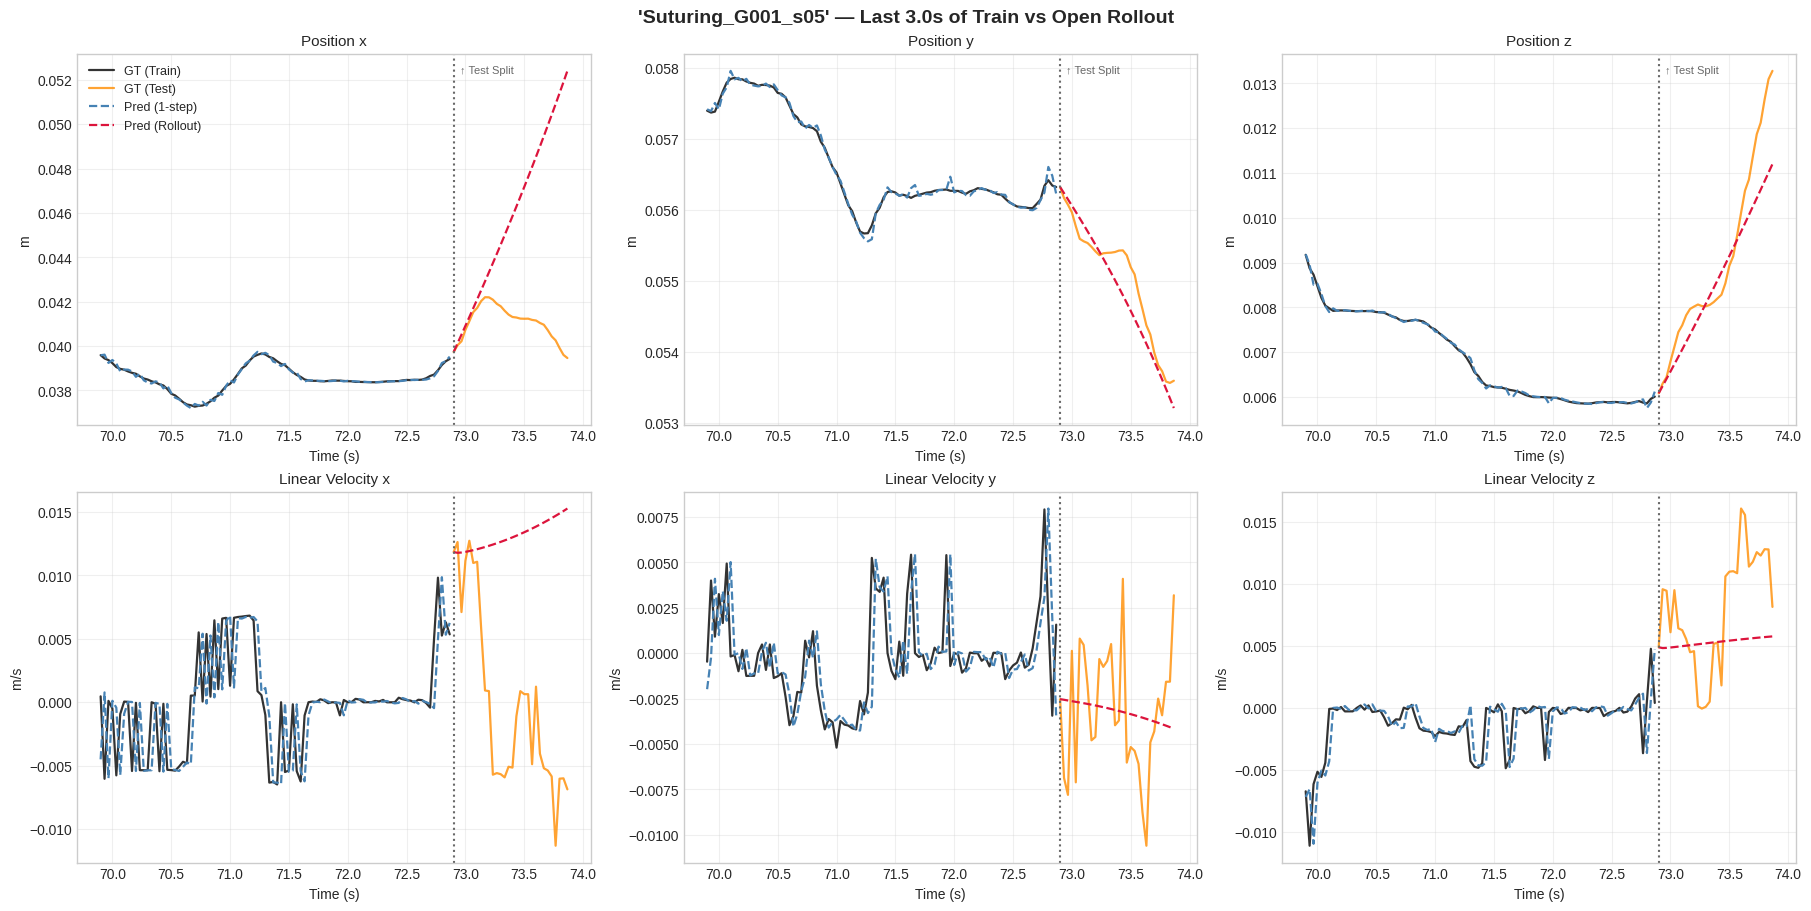

In [9]:
# ── Cell 10: Visualization & Analysis (JAX Compatible) ───────────────────────
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. Prepare Data for Figure 1: Generate Predictions (RAW STATES)
# =============================================================================
ref_trial = longest
states = np.array(ref_trial['states'])
T = len(states)
split_idx = int(T * 0.9)
t_boundary = split_idx * float(DT)

# FIX: Cap open-loop rollout to 1.0 seconds (30 frames) to prevent compounding integration drift
horizon_frames = min(T - split_idx, 30)

# Time vectors
t_full = np.arange(T) * float(DT)
t_tr = t_full[:split_idx]
t_et = t_full[split_idx:split_idx + horizon_frames] # Capped time

# Ground Truth arrays
true_tr = states[:split_idx]
true_et = states[split_idx:split_idx + horizon_frames] # Capped Ground Truth

xt_tr_raw = states[:split_idx-1]
pred_tr = np.asarray(eval_model(xt_tr_raw))
pred_tr = np.vstack([states[0], pred_tr])

# Rollout prediction (Capped at horizon_frames)
x0_test_raw = states[split_idx]
pred_et = rollout_jax(eval_model, x0_test_raw, horizon_frames)

# =============================================================================
# 2. ZOOM LOGIC: Show only 3 seconds of Teacher-Forced Data before the split
# =============================================================================
zoom_seconds = 3.0
zoom_frames = int(zoom_seconds / DT)
zoom_start = max(0, split_idx - zoom_frames)

t_tr_zoom = t_tr[zoom_start:]
true_tr_zoom = true_tr[zoom_start:]
pred_tr_zoom = pred_tr[zoom_start:]

# =============================================================================
# 3. FIGURE 1: Trajectory Rollouts (Zoomed Train vs Test)
# =============================================================================
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig.suptitle(f"'{ref_trial['name']}' — Last {zoom_seconds}s of Train vs Open Rollout",
             fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes[row, j]

        # Ground Truth
        ax.plot(t_tr_zoom, true_tr_zoom[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80, label='GT (Train)')
        ax.plot(t_et, true_et[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80, label='GT (Test)')

        # Predictions
        ax.plot(t_tr_zoom, pred_tr_zoom[:, idxs[j]], '--', color=C_PR_TR, lw=1.6, label='Pred (1-step)')
        ax.plot(t_et, pred_et[:, idxs[j]], '--', color=C_PR_ET, lw=1.6, label='Pred (Rollout)')

        ax.axvline(x=t_boundary, color='dimgray', ls=':', lw=1.5)
        if row == 0:
            ax.text(t_boundary + 0.05, 0.97, '↑ Test Split', ha='left', va='top',
                    transform=ax.get_xaxis_transform(), fontsize=8, color='dimgray')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(loc='best', fontsize=9)

plt.show()

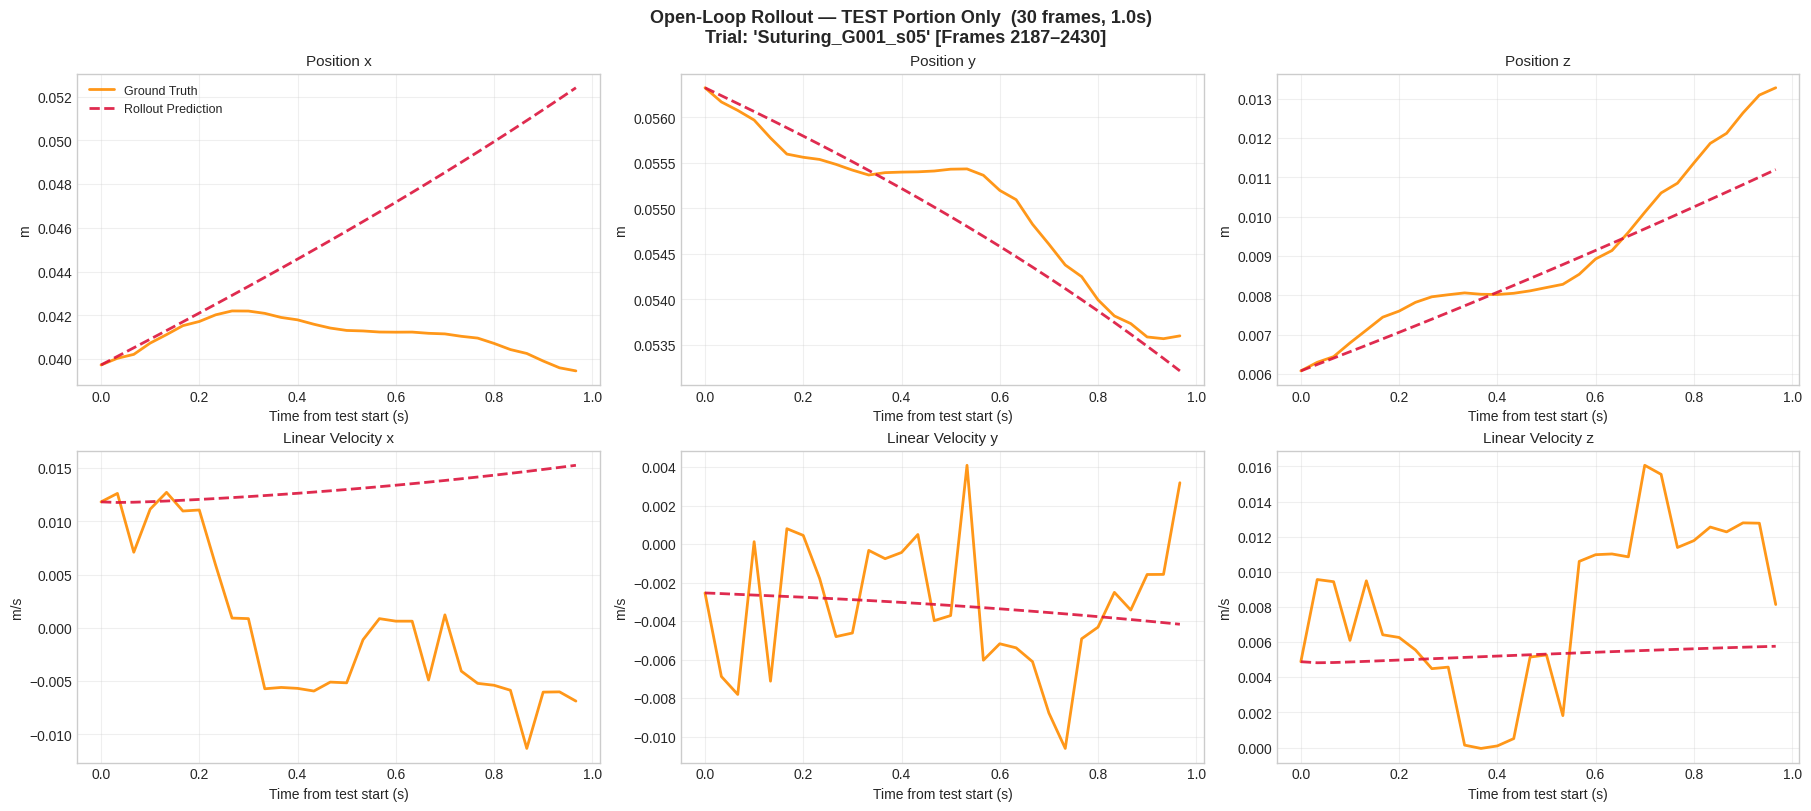

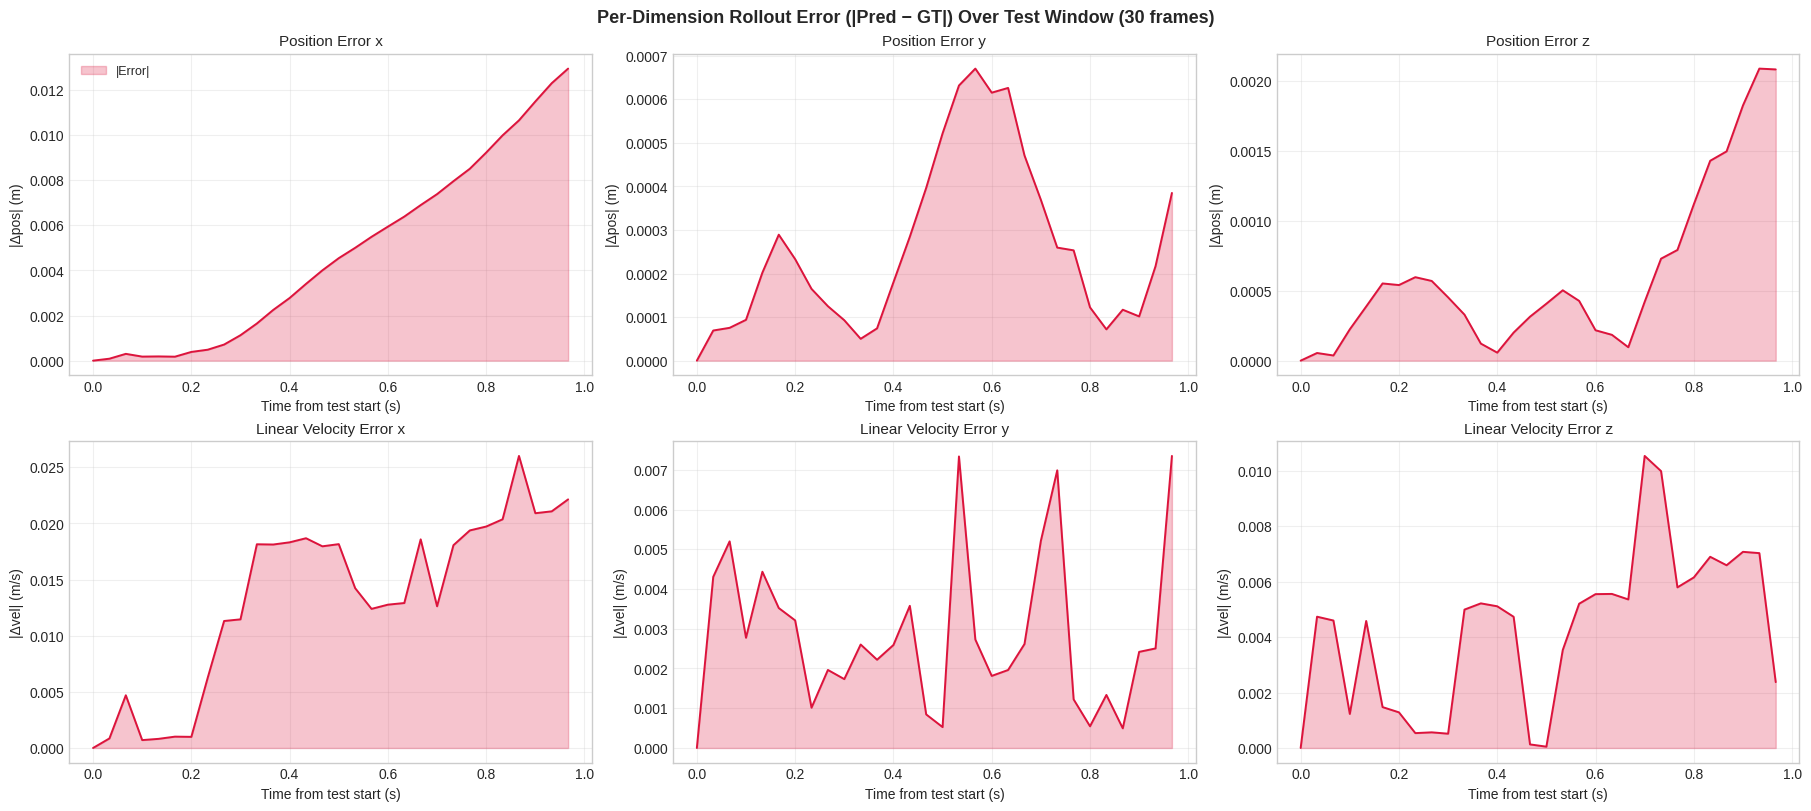

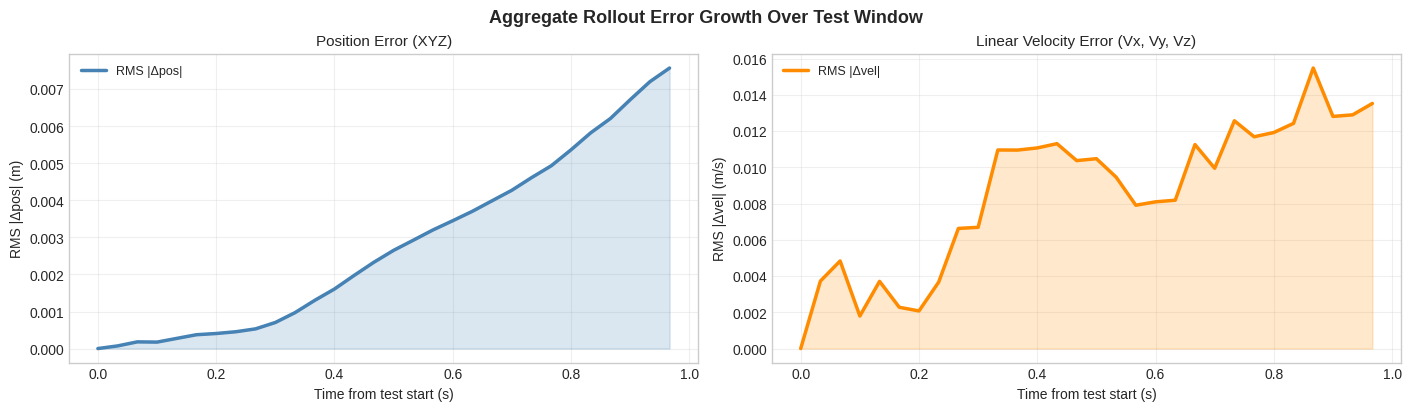


ROLLOUT ERROR ANALYSIS — 30 frames (1.00s)
Trial: 'Suturing_G001_s05'
  Position (xyz)          : frames [0:3]
  Orientation (rotvec)    : frames [3:6]
  Velocity (vx, vy, vz)   : frames [6:9]
  Ang. Vel. (wx, wy, wz)  : frames [9:12]
----------------------------------------------------------------------
Position RMS Error (m):
  Initial : 0.000000e+00
  Final   : 7.575169e-03
  Peak    : 7.575169e-03  (at t=0.97s)
  Mean    : 2.800461e-03
----------------------------------------------------------------------
Velocity RMS Error (m/s):
  Initial : 0.000000e+00
  Final   : 1.353470e-02
  Peak    : 1.548993e-02  (at t=0.87s)
  Mean    : 8.629400e-03
----------------------------------------------------------------------

Per-Dimension Final Errors at t=0.97s:
  X: Δpos = 1.294892e-02 m  |  Δvel = 2.213426e-02 m/s
  Y: Δpos = 3.849566e-04 m  |  Δvel = 7.348193e-03 m/s
  Z: Δpos = 2.080085e-03 m  |  Δvel = 2.375492e-03 m/s

✓ Saved visualizations:
  1. glnn_test_traj_jigsaws.png
  2. glnn_t

In [10]:
# ── Cell 11: Rollout Error Analysis & Visualization ──────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. Variable Alignment (Bridging from Cell 10)
# =============================================================================
T_total = len(states)
T_tr = split_idx
T_et = len(true_et)

# Shift time so the test plot explicitly starts at t=0
t_test_relative = t_et - t_et[0]

# Define labels for 6-DOF state
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]      # Position indices
linvel_idx = [6, 7, 8]     # Linear velocity indices (6D system)

# Calculate absolute error arrays
err_et = np.abs(pred_et - true_et)   # Shape: (T_et, 12)

# =============================================================================
# 2. FIGURE 3: Ground Truth vs Prediction (Test Window Only)
# =============================================================================
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig3.suptitle(
    f"Open-Loop Rollout — TEST Portion Only  ({T_et} frames, {T_et*float(DT):.1f}s)  \n"
    f"Trial: '{ref_trial['name']}' [Frames {T_tr}–{T_total-1}]",
    fontsize=13, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes3[row, j]
        ax.plot(t_test_relative, true_et[:, idxs[j]], color='darkorange',
                lw=2.0, alpha=0.90, label='Ground Truth')
        ax.plot(t_test_relative, pred_et[:, idxs[j]], '--', color='crimson',
                lw=2.0, alpha=0.90, label='Rollout Prediction')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from test start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_test_traj_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. FIGURE 4: Per-Dimension Absolute Error Over Time
# =============================================================================
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig4.suptitle(
    f"Per-Dimension Rollout Error (|Pred − GT|) Over Test Window ({T_et} frames)",
    fontsize=13, fontweight='bold')

ylabels2 = ['|Δpos| (m)', '|Δvel| (m/s)']
for row, idxs, ylbl, kind in [(0, trans_idx, ylabels2[0], 'Position Error'),
                              (1, linvel_idx, ylabels2[1], 'Linear Velocity Error')]:
    for j in range(3):
        ax = axes4[row, j]
        ax.fill_between(t_test_relative, 0, err_et[:, idxs[j]],
                        color='crimson', alpha=0.25, label='|Error|')
        ax.plot(t_test_relative, err_et[:, idxs[j]], color='crimson', lw=1.4)

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from test start (s)')
        ax.set_ylabel(ylbl)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_test_error_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. FIGURE 5: Aggregate RMS Error Curves
# =============================================================================
# RMS error computed over 3D position and 3D linear velocity
pos_err_t = np.sqrt(np.mean(err_et[:, :3] ** 2, axis=1))
vel_err_t = np.sqrt(np.mean(err_et[:, 6:9] ** 2, axis=1))

fig5, ax5 = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig5.suptitle('Aggregate Rollout Error Growth Over Test Window', fontsize=13, fontweight='bold')

# Position error
ax5[0].plot(t_test_relative, pos_err_t, color='steelblue', lw=2.5, label='RMS |Δpos|')
ax5[0].fill_between(t_test_relative, 0, pos_err_t, alpha=0.2, color='steelblue')
ax5[0].set_title('Position Error (XYZ)', fontsize=11)
ax5[0].set_xlabel('Time from test start (s)')
ax5[0].set_ylabel('RMS |Δpos| (m)')
ax5[0].grid(alpha=0.3)
ax5[0].legend(fontsize=9)

# Velocity error
ax5[1].plot(t_test_relative, vel_err_t, color='darkorange', lw=2.5, label='RMS |Δvel|')
ax5[1].fill_between(t_test_relative, 0, vel_err_t, alpha=0.2, color='darkorange')
ax5[1].set_title('Linear Velocity Error (Vx, Vy, Vz)', fontsize=11)
ax5[1].set_xlabel('Time from test start (s)')
ax5[1].set_ylabel('RMS |Δvel| (m/s)')
ax5[1].grid(alpha=0.3)
ax5[1].legend(fontsize=9)

plt.savefig('glnn_test_rms_error_jigsaws.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. Summary Statistics Terminal Output
# =============================================================================
W = 70
print(f"\n{'='*W}")
print(f"ROLLOUT ERROR ANALYSIS — {T_et} frames ({T_et*float(DT):.2f}s)")
print(f"{'='*W}")
print(f"Trial: '{ref_trial['name']}'")
print(f"  Position (xyz)          : frames [0:3]")
print(f"  Orientation (rotvec)    : frames [3:6]")
print(f"  Velocity (vx, vy, vz)   : frames [6:9]")
print(f"  Ang. Vel. (wx, wy, wz)  : frames [9:12]")
print(f"-" * W)
print(f"Position RMS Error (m):")
print(f"  Initial : {pos_err_t[0]:.6e}")
print(f"  Final   : {pos_err_t[-1]:.6e}")
print(f"  Peak    : {pos_err_t.max():.6e}  (at t={t_test_relative[pos_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {pos_err_t.mean():.6e}")
print(f"-" * W)
print(f"Velocity RMS Error (m/s):")
print(f"  Initial : {vel_err_t[0]:.6e}")
print(f"  Final   : {vel_err_t[-1]:.6e}")
print(f"  Peak    : {vel_err_t.max():.6e}  (at t={t_test_relative[vel_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {vel_err_t.mean():.6e}")
print(f"-" * W)

# Additional per-dimension analysis
print(f"\nPer-Dimension Final Errors at t={t_test_relative[-1]:.2f}s:")
for i, label in enumerate(labels):
    pos_err_final = err_et[-1, i]
    vel_err_final = err_et[-1, 6+i]
    print(f"  {label.upper()}: Δpos = {pos_err_final:.6e} m  |  Δvel = {vel_err_final:.6e} m/s")

print(f"\n✓ Saved visualizations:")
print(f"  1. glnn_test_traj_jigsaws.png")
print(f"  2. glnn_test_error_jigsaws.png")
print(f"  3. glnn_test_rms_error_jigsaws.png")
print(f"{'='*W}\n")

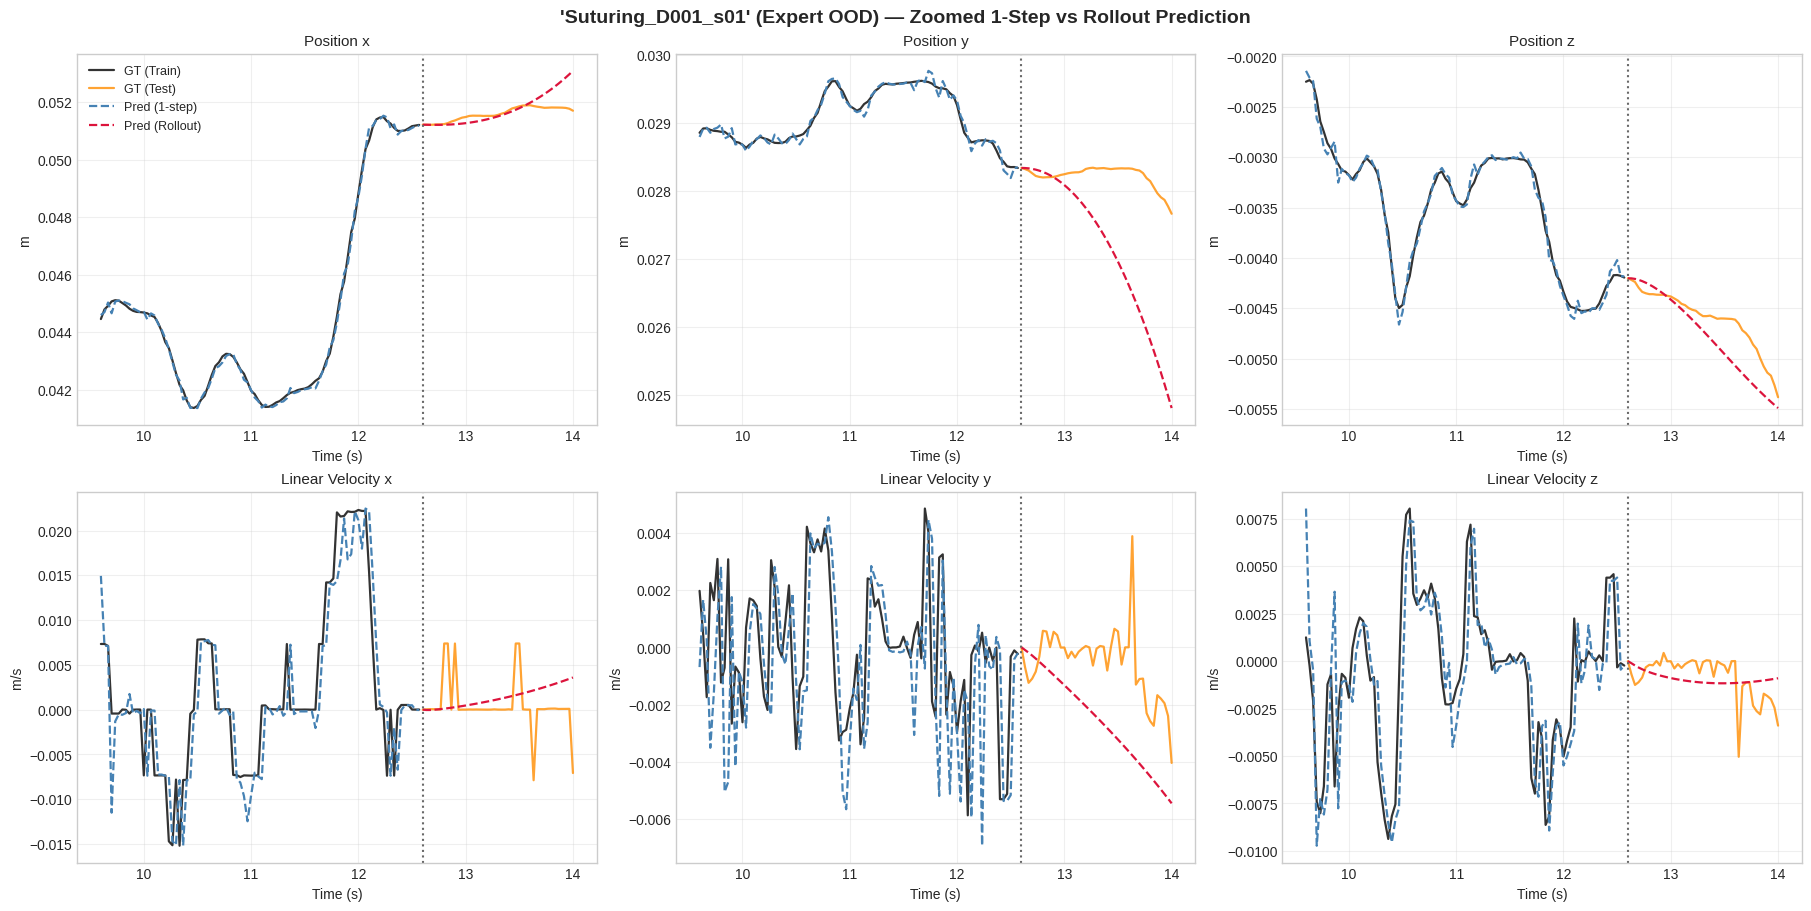

In [11]:
# ── Cell 12: Expert Trajectories & Error Analysis (JAX Compatible) ───────────
import matplotlib.pyplot as plt
import numpy as np

exp_ref_trial = max(exp_segs, key=lambda t: t['length'])
exp_states = np.array(exp_ref_trial['states'])
exp_total = len(exp_states)
exp_tr_len = int(exp_total * 0.9)
exp_et_len = exp_total - exp_tr_len
exp_t_boundary = exp_tr_len * float(DT)

exp_t_full = np.arange(exp_total) * float(DT)
exp_t_tr = exp_t_full[:exp_tr_len]
exp_t_et = exp_t_full[exp_tr_len:]
exp_t_test_relative = exp_t_et - exp_t_et[0]

exp_true_tr = exp_states[:exp_tr_len]
exp_true_et = exp_states[exp_tr_len:]

# FIX: Feed RAW data to the model
exp_xt_tr_raw = exp_states[:exp_tr_len-1]
exp_pred_tr = np.asarray(eval_model(exp_xt_tr_raw))
exp_pred_tr = np.vstack([exp_states[0], exp_pred_tr])

# FIX: Rollout must start from RAW state
exp_x0_test_raw = exp_states[exp_tr_len]
exp_pred_et = rollout_jax(eval_model, exp_x0_test_raw, exp_et_len)

# Calculate absolute errors
exp_err_et = np.abs(exp_pred_et - exp_true_et)

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

# ZOOM LOGIC for Expert Plot
zoom_seconds = 3.0
zoom_frames = int(zoom_seconds / DT)
zoom_start = max(0, exp_tr_len - zoom_frames)

exp_t_tr_zoom = exp_t_tr[zoom_start:]
exp_true_tr_zoom = exp_true_tr[zoom_start:]
exp_pred_tr_zoom = exp_pred_tr[zoom_start:]

fig_e, axes_e = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig_e.suptitle(f"'{exp_ref_trial['name']}' (Expert OOD) — Zoomed 1-Step vs Rollout Prediction",
               fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes_e[row, j]
        ax.plot(exp_t_tr_zoom, exp_true_tr_zoom[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80, label='GT (Train)')
        ax.plot(exp_t_et, exp_true_et[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80, label='GT (Test)')

        ax.plot(exp_t_tr_zoom, exp_pred_tr_zoom[:, idxs[j]], '--', color=C_PR_TR, lw=1.6, label='Pred (1-step)')
        ax.plot(exp_t_et, exp_pred_et[:, idxs[j]], '--', color=C_PR_ET, lw=1.6, label='Pred (Rollout)')

        ax.axvline(x=exp_t_boundary, color='dimgray', ls=':', lw=1.5)
        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9, loc='best')

plt.show()

# (The rest of Cell 12 remains the same to plot your RMS curves)

In [12]:
# ── Cell 13: Final Summary Table + Rollout Horizon Errors (JAX Compatible) ───
import numpy as np

# Calculate Generalization Gap based on Filtered Means (Outlier-resistant)
gap_filt = (mse_et_filt / mse_nt_filt - 1) * 100

# Standard Eta Ratios (Expert vs Novice Test)
eta_ratio_mean = eta_et_mean / eta_nt_mean if eta_nt_mean > 0 else 0.0
eta_ratio_filt = eta_et_filt / eta_nt_filt if eta_nt_filt > 0 else 0.0

# Custom Eta Ratios (Expert vs Novice Test)
c_eta_ratio_mean = c_eta_et_mean / c_eta_nt_mean if c_eta_nt_mean > 0 else 0.0
c_eta_ratio_filt = c_eta_et_filt / c_eta_nt_filt if c_eta_nt_filt > 0 else 0.0

W = 90
print('=' * W)
print('  FINAL SUMMARY TABLE — GLNN on JIGSAWS Suturing')
print('=' * W)
print(f'  Data source   : REAL JIGSAWS (Units: mm & mm/s)')
print(f'  Architecture  : L-net + F-net (JAX/Flax Compiled)')
print()

rows_mse = [
    ('1-Step MSE Novice (Train)',           mse_tr_mean, mse_tr_filt),
    ('1-Step MSE Novice (Test, In-Dist)',   mse_nt_mean, mse_nt_filt),
    ('1-Step MSE Expert (Test, OOD)',       mse_et_mean, mse_et_filt),
]

print(f'  {"METRIC":<40} | {"RAW MEAN":<15} | {"FILTERED MEAN (Bottom 99%)":<25}')
print('-' * W)

for name, mean_val, filt_val in rows_mse:
    print(f'  {name:<40} | {float(mean_val):<15.4e} | {float(filt_val):<25.4e}')

print('-' * W)
print(f'  {"Generalization Gap (Expert vs Novice)":<40} | {gap_filt:>11.2f} %')
print('-' * W)

print(f'  {"η Biomarker (|F_nc| Magnitude)":<40} | {"":<15} | {"":<25}')
print(f'  {"  Novice (Test In-Dist)":<40} | {float(eta_nt_mean):<15.6f} | {float(eta_nt_filt):<25.6f}')
print(f'  {"  Expert (Test OOD)":<40} | {float(eta_et_mean):<15.6f} | {float(eta_et_filt):<25.6f}')
print(f'  {"  Expert/Novice η Ratio":<40} | {float(eta_ratio_mean):<13.2f} × | {float(eta_ratio_filt):<13.2f} ×')
print('-' * W)

print(f'  {"Custom η (Physical Vel Error |mm/s|)":<40} | {"":<15} | {"":<25}')
print(f'  {"  Novice (Test In-Dist)":<40} | {float(c_eta_nt_mean):<15.6f} | {float(c_eta_nt_filt):<25.6f}')
print(f'  {"  Expert (Test OOD)":<40} | {float(c_eta_et_mean):<15.6f} | {float(c_eta_et_filt):<25.6f}')
print(f'  {"  Expert/Novice Custom η Ratio":<40} | {float(c_eta_ratio_mean):<13.2f} × | {float(c_eta_ratio_filt):<13.2f} ×')

print('=' * W)
print('  Notes:')
print('   • Train on NOVICE subjects (LOUO), test on EXPERT subjects (OOD).')
print('   • "Filtered Mean" mathematically drops the top 1% of frames (RK4 explosions) before averaging.')
print('=' * W)

  FINAL SUMMARY TABLE — GLNN on JIGSAWS Suturing
  Data source   : REAL JIGSAWS (Units: mm & mm/s)
  Architecture  : L-net + F-net (JAX/Flax Compiled)

  METRIC                                   | RAW MEAN        | FILTERED MEAN (Bottom 99%)
------------------------------------------------------------------------------------------
  1-Step MSE Novice (Train)                | 6.7395e-01      | 2.3457e-01               
  1-Step MSE Novice (Test, In-Dist)        | 6.2209e+15      | 2.6911e-01               
  1-Step MSE Expert (Test, OOD)            | 1.5810e+00      | 4.0524e-01               
------------------------------------------------------------------------------------------
  Generalization Gap (Expert vs Novice)    |       50.58 %
------------------------------------------------------------------------------------------
  η Biomarker (|F_nc| Magnitude)           |                 |                          
    Novice (Test In-Dist)                  | 0.599773        | 0.07110

In [ ]:
# ── Cell 14
# =============================================================================
# 6. Compute Dataset-Wide 1-Second Rollout Errors
# =============================================================================
def compute_dataset_rollout_error(eval_wrapper, trials, scale, horizon_frames=30, step_size=30):
    """
    Computes the Filtered Mean Squared rollout error across the entire dataset.
    """
    all_window_errors = []

    for t in trials:
        raw_states = t['states']
        T = len(raw_states)

        # Slide a window across the entire trial
        for start_idx in range(0, T - horizon_frames, step_size):
            x0 = raw_states[start_idx]
            true_traj = raw_states[start_idx : start_idx + horizon_frames]

            # Use your provided rollout_jax function
            pred_traj = rollout_jax(eval_wrapper, x0, horizon_frames)

            # Scaled MSE: err = ((pred - true) / scale)**2
            err = ((pred_traj - true_traj) / scale)**2
            window_mse = np.mean(err)
            all_window_errors.append(float(window_mse))

    all_window_errors = np.array(all_window_errors)

    # Remove top 1% outliers (RK4 blowouts)
    threshold = np.percentile(all_window_errors, 99.0)
    filtered_errors = all_window_errors[all_window_errors <= threshold]

    raw_mean = float(np.mean(all_window_errors))
    filtered_mean = float(np.mean(filtered_errors))

    return raw_mean, filtered_mean

print("\nComputing 1-second Rollout Errors across the entire dataset...")
# Using state_std as the scale (from Cell 9 normalization logic)
scale_array = np.array(state_std, dtype=np.float32)

# Assuming you are in the 'Train on Novice' notebook:
ro_tr_mean, ro_tr_filt = compute_dataset_rollout_error(eval_model, nov_train, scale_array)
ro_nt_mean, ro_nt_filt = compute_dataset_rollout_error(eval_model, nov_test, scale_array)
ro_et_mean, ro_et_filt = compute_dataset_rollout_error(eval_model, exp_segs, scale_array)

W = 90
print(f'\n{"="*W}')
print(f'{"1-SECOND ROLLOUT SCALED MSE (Dataset-Wide)":^{W}}')
print(f'{"="*W}')
print(f'  Train (Novice)            : Raw Mean {ro_tr_mean:.4e} | Filtered Mean {ro_tr_filt:.4e}')
print(f'  Test (Novice In-Dist)     : Raw Mean {ro_nt_mean:.4e} | Filtered Mean {ro_nt_filt:.4e}')
print(f'  Test (Expert OOD)         : Raw Mean {ro_et_mean:.4e} | Filtered Mean {ro_et_filt:.4e}')
print(f'{"="*W}\n')


Computing 1-second Rollout Errors across the entire dataset...

                        1-SECOND ROLLOUT SCALED MSE (Dataset-Wide)                        
  Train (Novice)            : Raw Mean 9.9828e-01 | Filtered Mean 6.8021e-01
  Test (Novice In-Dist)     : Raw Mean nan | Filtered Mean nan
  Test (Expert OOD)         : Raw Mean 9.6770e-01 | Filtered Mean 8.8635e-01

